In [ ]:
import os
print(os.getpid())

In [45]:
from sequenceHandler import mapPDBToHMM

pfam_id = "PF00014"
#contanct map of the PDB and sequence
pdb_file = f"C:/Users/gfabi/Desktop/Internship/PDB/{pfam_id}.pdb"
chain_id = "A"
hmm_file = f"C:/Users/gfabi/Desktop/Internship/HMM/{pfam_id}.hmm"
hmm_file_2 = "None"        
output_map_file = "None"  

distance_map_pdb,map_index,aligned_sequence = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='all')

c:\Users\gfabi\miniconda3\envs\Internship\Lib\site-packages\Bio\PDB\Atom.py:237: PDBConstructionWarning: Used element 'U' for Atom (name=UNK) with given element 'X'
  warnings.warn(msg, PDBConstructionWarning)


STDERR: 


In [46]:
print(distance_map_pdb)

[[0.         1.33242851 2.60380922 ... 2.14929082 3.68233897        inf]
 [1.33242851 0.         1.29087005 ... 3.52894769 2.04304766        inf]
 [2.60380922 1.29087005 0.         ... 8.10487206 5.97459485        inf]
 ...
 [2.14929082 3.52894769 8.10487206 ... 0.         1.33761117        inf]
 [3.68233897 2.04304766 5.97459485 ... 1.33761117 0.                inf]
 [       inf        inf        inf ...        inf        inf        inf]]


In [47]:
import numpy as np

def rank_links(distance_matrix):
    D = np.array(distance_matrix)
    
    # Get indices of upper triangle (k=1 excludes diagonal)
    i_indices, j_indices = np.triu_indices_from(D, k=1)
    
    # Extract corresponding distances
    distances = D[i_indices, j_indices]
    
    # Sort by distance
    sorted_idx = np.argsort(distances)
    
    # Build sorted list of (i, j, distance)
    ranked_links = [
        (int(i_indices[k]), int(j_indices[k]), float(distances[k]))
        for k in sorted_idx
    ]
    
    return ranked_links

In [48]:
links = rank_links(distance_map_pdb)

print(len(links))
for link in links:
    print(link)

1378
(39, 40, 1.275325766499014)
(32, 33, 1.2818224597566494)
(35, 36, 1.2818999460849354)
(48, 49, 1.2864570904638357)
(6, 7, 1.2878280430708233)
(38, 39, 1.2878333773123636)
(1, 2, 1.2908700534687192)
(9, 10, 1.291273138986095)
(7, 8, 1.2921102174672086)
(11, 12, 1.295893761502887)
(33, 34, 1.2966689704863912)
(43, 44, 1.2968957109331862)
(29, 30, 1.299438710592687)
(12, 13, 1.2998662176606857)
(21, 22, 1.3005968981078535)
(25, 26, 1.300834146300581)
(24, 25, 1.3051535530750782)
(3, 4, 1.3054522928385102)
(5, 6, 1.30631673073353)
(36, 37, 1.30719482877517)
(34, 35, 1.311771290506123)
(14, 15, 1.3145677518400438)
(41, 42, 1.315572341996231)
(26, 27, 1.316438095202625)
(20, 21, 1.317793024870871)
(30, 31, 1.3186727158565585)
(16, 17, 1.3188340761232356)
(22, 23, 1.3204374070159028)
(46, 47, 1.323363903799918)
(45, 46, 1.3236423906082573)
(2, 3, 1.3241795701247363)
(44, 45, 1.324348510804688)
(31, 32, 1.3254468727822122)
(13, 14, 1.3259145523436873)
(23, 24, 1.3287952792644815)
(17, 18,

In [49]:
import random
def select_link(links,percentage_to_keep = 0.1, percentage_of_noise_added=0.1):
    #percentage of the total number of links to keep
    percentage_to_keep = 0.1
    #noise
    percentage_of_noise_added=0.1
    num_links_to_keep = int(len(links) * percentage_to_keep) 
    num_links_noise = int(len(links) * percentage_of_noise_added)   

    top_links = links[:num_links_to_keep]
    remaining_links = links[num_links_to_keep:]

    noise_links = random.sample(remaining_links, num_links_noise)

    # Combine
    final_links = top_links + noise_links
    return final_links


In [ ]:
def write_links_to_file(links, filename):

    with open(filename, "w") as f:
        for i, j, d in links:
            f.write(f"2,{i},{j},{1.0}\n")

write_links_to_file(distance_map_pdb, f"Links/top_{percentage_to_keep*100}%_links_{pfam_id}_noise_{percentage_of_noise_added*100}%.txt")



In [54]:
percentage_to_keep=0.5
percentage_of_noise_added=0.0
links = rank_links(distance_map_pdb)
final_links = select_link(links, percentage_to_keep, percentage_of_noise_added)
write_links_to_file(final_links, f"Links/top_{percentage_to_keep*100}%_links_{pfam_id}_noise_{percentage_of_noise_added*100}%.txt")

In [ ]:
#Della magia viene fatta e ottengo un file GSE_output.txt con numero nodo, posizione x, posizione y, posizione z

In [18]:
import numpy as np

def load_coordinates(filename):
    data = np.loadtxt(filename, delimiter=",")
    
    node_ids = data[:, 0].astype(int)
    coords = data[:, 1:4]  # x, y, z
    
    return node_ids, coords


def compute_distance_matrix(coords):
    n = len(coords)
    dist_matrix = [[0.0]*n for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            dx = coords[i][0] - coords[j][0]
            dy = coords[i][1] - coords[j][1]
            dz = coords[i][2] - coords[j][2]
            dist_matrix[i][j] = (dx**2 + dy**2 + dz**2) ** 0.5
            
    return dist_matrix


In [31]:
filename = "GSE_output.txt" 
node_ids, coords = load_coordinates(filename)
distance_map_simul = compute_distance_matrix(coords)

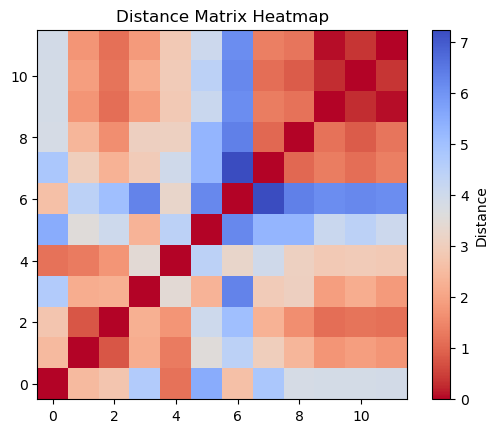

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(distance_map_simul,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Matrix Heatmap")
plt.show()

In [33]:
#Pearson correlation coefficient

def compare_distance_maps(D1, D2):
    D1 = np.array(D1)
    D2 = np.array(D2)
    
    # Extract upper triangle
    i, j = np.triu_indices_from(D1, k=1)
    
    v1 = D1[i, j]
    v2 = D2[i, j]
    
    # Pearson correlation
    corr = np.corrcoef(v1, v2)[0, 1]
    
    return corr

In [34]:
score=compare_distance_maps(distance_map_pdb, distance_map_simul)

IndexError: index 12 is out of bounds for axis 0 with size 12